# Chapter 9a — Carbon Budget Accounting

This notebook covers carbon budget accounting (despite living under a
"Risk Measures" chapter heading, the material here is carbon-accounting
and climate-transition analysis, not financial risk measures like
VaR/ES). A *carbon budget* CB$(t_0, t)$ is simply the cumulative
emissions $\int_{t_0}^{t} CE(s)\,ds$ over some horizon — this notebook
builds up the concept from the historical/expected/net decomposition,
through three closed-form emission-reduction models (linear, compound,
exponential decay), a piecewise-linear multi-period budget calculator,
probability-weighted budget thresholds (tied to different odds of
staying under a warming target), and finally two worked sector/global
emissions-scenario budgets.

Two helper functions are defined below to support this:
`carbon_budget_Reduction`, which implements the three closed-form
reduction models directly from their formulas, and
`carbon_budget_piecewise`, which linearly interpolates through a set of
knot points and numerically integrates to compute a budget over an
arbitrary interval — see each function's docstring for details.

No external data dependency in this notebook — every series is a
hardcoded illustrative scenario.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline, interp1d
from scipy.integrate import quad

color_blue       = np.array([  0,  20, 255]) / 255
color_red        = np.array([255,  80,  50]) / 255
color_green      = np.array([ 20, 200,  80]) / 255
color_violet     = np.array([255,  51, 255]) / 255
color_teal       = np.array([ 56, 142, 142]) / 255
color_coral      = np.array([255, 127,  80]) / 255
color_skyblue    = np.array([135, 206, 235]) / 255
color_gray       = np.array([150, 150, 150]) / 255
color_darkorange = np.array([255, 140,   0]) / 255
color_black      = np.array([0, 0, 0])

def carbon_budget_Reduction(t0, t, CE_t0, R, mtd):
    # Closed-form emissions-reduction models:
    #   mtd=1: linear decline,      CE(s) = CE_t0 - R*(s-t0)
    #   mtd=2: compound decline,    CE(s) = CE_t0*(1-R)**(s-t0)
    #   mtd=3: exponential decline, CE(s) = CE_t0*exp(-R*(s-t0))
    # Returns (CB_numeric, CB_closed_form) -- both computed independently so
    # the two can be cross-checked against each other.
    if mtd == 1:
        fun = lambda s: CE_t0 - R * (s - t0)
        CB2 = (t - t0) * CE_t0 - 0.5 * ((t - t0) ** 2) * R
    elif mtd == 2:
        fun = lambda s: CE_t0 * ((1 - R) ** (s - t0))
        CB2 = ((1 - R) ** (t - t0) - 1) / np.log(1 - R) * CE_t0
    elif mtd == 3:
        fun = lambda s: CE_t0 * np.exp(-R * (s - t0))
        CB2 = (1 - np.exp(-R * (t - t0))) / R * CE_t0
    else:
        raise ValueError("mtd must be 1, 2, or 3")
    CB1, _ = quad(fun, t0, t)
    return CB1, CB2

def carbon_budget_piecewise(t0, t, t_k, CE_k):
    # Linear interpolation through the knot points (t_k, CE_k), then
    # numerical integration over [t0, t]. Returns three outputs:
    #   CB1: numerically-integrated budget (quad)
    #   CB2: trapezoidal-rule budget over the same interpolated knots (cross-check)
    #   CB3: |CB1 - CB2|, a consistency-check magnitude
    f = interp1d(t_k, CE_k, kind="linear", fill_value="extrapolate")
    CB1, _ = quad(f, t0, t)
    knots_in_range = t_k[(t_k > t0) & (t_k < t)]
    tt = np.unique(np.concatenate([[t0], knots_in_range, [t]]))
    yy = f(tt)
    CB2 = np.trapezoid(yy, tt)
    CB3 = abs(CB1 - CB2)
    return CB1, CB2, CB3


## 1. Past, expected, and net carbon budgets

The historical (2010-2020) and an illustrative net-zero-by-2050 pathway
(2020-2050), spline-interpolated, with the area under each curve shaded
to visualize the "past" and "expected" carbon budgets. The bottom two
panels illustrate a *net* budget against a hypothetical remaining-budget
target $\mathcal{CE}^\star$: when the pathway exceeds the target the
excess is marked "$+$" (budget overspend), and when it's under, "$-$"
(budget headroom).


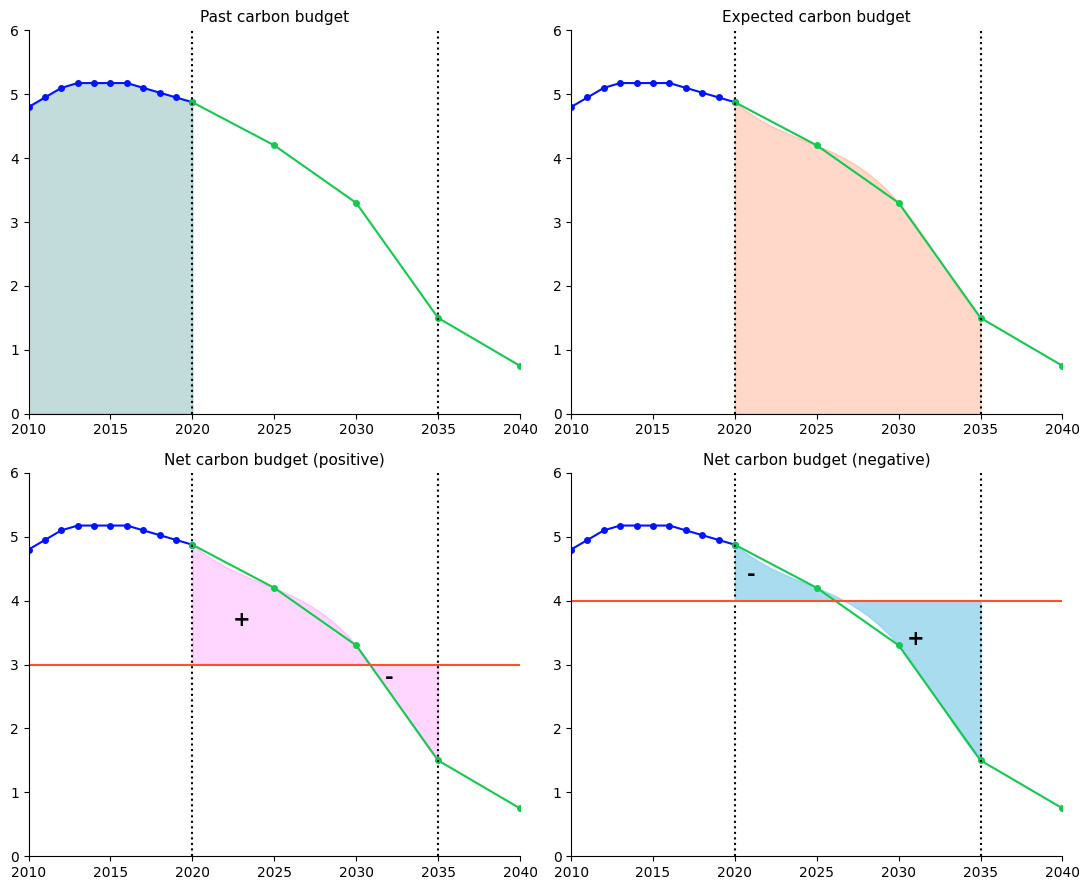

CB(2010, 2020) = 50.625 GtCO2e  (sum of annual emissions, a discrete/left-Riemann approximation of the integral)


In [2]:

t1 = np.arange(2010, 2021)
CE1 = np.array([4.800, 4.950, 5.100, 5.175, 5.175, 5.175, 5.175, 5.100, 5.025, 4.950, 4.875])

t2 = np.array([2020, 2025, 2030, 2035, 2040, 2050])
CE2 = np.array([4.875, 4.200, 3.300, 1.500, 0.750, 0.150])

CE_star = [0.0, 0.0, 3.0, 4.0]
titles = ["Past carbon budget", "Expected carbon budget", "Net carbon budget (positive)", "Net carbon budget (negative)"]
fill_colors = [color_teal, color_coral, color_violet, color_skyblue]
fill_alphas = [0.30, 0.30, 0.20, 0.70]

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
cs1 = CubicSpline(t1, CE1)
cs2 = CubicSpline(t2, CE2)

for i, ax in enumerate(axes.flat):
    ax.plot(t1, CE1, "-o", color=color_blue, linewidth=1.5, markersize=4)
    ax.plot(t2, CE2, "-o", color=color_green, linewidth=1.5, markersize=4)

    if i == 0:
        x = np.arange(2010, 2020.01, 0.1)
        y = cs1(x)
    else:
        x = np.arange(2020, 2035.01, 0.01)
        y = cs2(x)
    z = np.full_like(y, CE_star[i])
    ax.fill_between(x, y, z, color=fill_colors[i], alpha=fill_alphas[i])

    ax.axvline(2020, linestyle=":", color=color_black, linewidth=1.5)
    ax.axvline(2035, linestyle=":", color=color_black, linewidth=1.5)
    if i in (2, 3):
        ax.axhline(CE_star[i], color=color_red, linewidth=1.5)
    if i == 2:
        ax.text(2023, 3.6, "+", fontsize=15, fontweight="bold", ha="center")
        ax.text(2032, 2.7, "-", fontsize=15, fontweight="bold", ha="center")
    elif i == 3:
        ax.text(2021, 4.3, "-", fontsize=15, fontweight="bold", ha="center")
        ax.text(2031, 3.3, "+", fontsize=15, fontweight="bold", ha="center")

    ax.set_title(titles[i], fontsize=11)
    ax.set_xlim(2010, 2040); ax.set_ylim(0, 6)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

CB_2010_2020 = CE1[:10].sum()
print(f"CB(2010, 2020) = {CB_2010_2020:.3f} GtCO2e  (sum of annual emissions, a discrete/left-Riemann approximation of the integral)")


## 2. Three closed-form reduction models

Given a starting emissions level $\mathcal{CE}(t_0)$ and a reduction rate
$R$, three natural models for how emissions decline over $[t_0, t]$, each
with a closed-form budget alongside the numerically-integrated one, plus
the `carbon_budget_Reduction` helper for the same three methods:

- **Linear**: $\mathcal{CE}(s) = \mathcal{CE}(t_0) - R\cdot(s-t_0)$
- **Compound**: $\mathcal{CE}(s) = \mathcal{CE}(t_0)\cdot(1-R)^{s-t_0}$
- **Exponential**: $\mathcal{CE}(s) = \mathcal{CE}(t_0)\cdot e^{-R(s-t_0)}$


In [3]:

t0, t = 2010, 2030
CE_t0 = CE1[0]
R = 0.10

rows = []
for label, fun, CB_closed in [
    ("Linear rate", lambda s: CE_t0 - R * (s - t0), (t - t0) * CE_t0 - 0.5 * ((t - t0) ** 2) * R),
    ("Compound rate", lambda s: CE_t0 * ((1 - R) ** (s - t0)), ((1 - R) ** (t - t0) - 1) / np.log(1 - R) * CE_t0),
    ("Exponential rate", lambda s: CE_t0 * np.exp(-R * (s - t0)), (1 - np.exp(-R * (t - t0))) / R * CE_t0),
]:
    CB_num, _ = quad(fun, t0, t)
    rows.append({"Method": label, "CB (numerical)": CB_num, "CB (closed form)": CB_closed,
                 "|diff| x 1e4": 1e4 * abs(CB_num - CB_closed)})

display(pd.DataFrame(rows).round(6))

print("\nCross-check against the reimplemented carbon_budget_Reduction helper:")
rows2 = []
for mtd, label in [(1, "Linear"), (2, "Compound"), (3, "Exponential")]:
    CB1, CB2 = carbon_budget_Reduction(t0, t, CE_t0, R, mtd)
    rows2.append({"Method": label, "CB1 (quad)": CB1, "CB2 (closed form)": CB2, "|diff| x 1e4": 1e4 * abs(CB1 - CB2)})
display(pd.DataFrame(rows2).round(6))


,Method,CB (numerical),CB (closed form),|diff| x 1e4
0,Linear rate,76.000000,76.000000,0.0
1,Compound rate,40.019091,40.019091,0.0
2,Exponential rate,41.503906,41.503906,0.0



Cross-check against the reimplemented carbon_budget_Reduction helper:


,Method,CB1 (quad),CB2 (closed form),|diff| x 1e4
0,Linear,76.000000,76.000000,0.0
1,Compound,40.019091,40.019091,0.0
2,Exponential,41.503906,41.503906,0.0


## 3. Piecewise-linear multi-period budgets

Splicing the historical and projected series into one set of knot points
and computing carbon budgets over various sub-intervals — including
checking that the budget over a full interval equals the sum of its
non-overlapping sub-interval budgets (up to interpolation-grid rounding).


In [4]:

t_k = np.concatenate([t1, t2[1:]])
CE_k = np.concatenate([CE1, CE2[1:]])

CB1, CB2, CB3 = carbon_budget_piecewise(2010, 2020, t_k, CE_k)
print(f"CB(2010, 2020): numerical={CB1:.3f}, trapezoidal={CB2:.3f}, |diff|={CB3:.2e}")

CB_2020_2035 = carbon_budget_piecewise(2020, 2035, t_k, CE_k)[0]
CB_2020_2025 = carbon_budget_piecewise(2020, 2025, t_k, CE_k)[0]
CB_2025_2030 = carbon_budget_piecewise(2025, 2030, t_k, CE_k)[0]
CB_2030_2035 = carbon_budget_piecewise(2030, 2035, t_k, CE_k)[0]
sub_sum = CB_2020_2025 + CB_2025_2030 + CB_2030_2035
print(f"\nCB(2020, 2035) = {CB_2020_2035:.3f}")
print(f"Sub-periods: 2020-25={CB_2020_2025:.3f}, 2025-30={CB_2025_2030:.3f}, 2030-35={CB_2030_2035:.3f}, sum={sub_sum:.3f}")
print(f"Ratio of each sub-period to the total: "
      f"{100*CB_2020_2025/CB_2020_2035:.1f}%, {100*CB_2025_2030/CB_2020_2035:.1f}%, {100*CB_2030_2035/CB_2020_2035:.1f}%")

CB_2020_2050 = carbon_budget_piecewise(2020, 2050, t_k, CE_k)[0]
CB_2020_2035b = carbon_budget_piecewise(2020, 2035, t_k, CE_k)[0]
CB_2035_2050 = carbon_budget_piecewise(2035, 2050, t_k, CE_k)[0]
print(f"\nCB(2020, 2050) = {CB_2020_2050:.3f}, split 2020-35={CB_2020_2035b:.3f} ({100*CB_2020_2035b/CB_2020_2050:.1f}%), "
      f"2035-50={CB_2035_2050:.3f} ({100*CB_2035_2050/CB_2020_2050:.1f}%)")


CB(2010, 2020): numerical=50.663, trapezoidal=50.663, |diff|=0.00e+00

CB(2020, 2035) = 53.437
Sub-periods: 2020-25=22.688, 2025-30=18.750, 2030-35=12.000, sum=53.438
Ratio of each sub-period to the total: 42.5%, 35.1%, 22.5%

CB(2020, 2050) = 63.562, split 2020-35=53.437 (84.1%), 2035-50=10.125 (15.9%)


## 4. Probability-weighted carbon budget thresholds

Compound-rate carbon budgets CB$(2019, t)$ at four reduction rates,
against three reference thresholds tied to the probability of staying
under a given temperature-rise target (a higher-probability/lower-risk
target corresponds to a smaller remaining carbon budget).


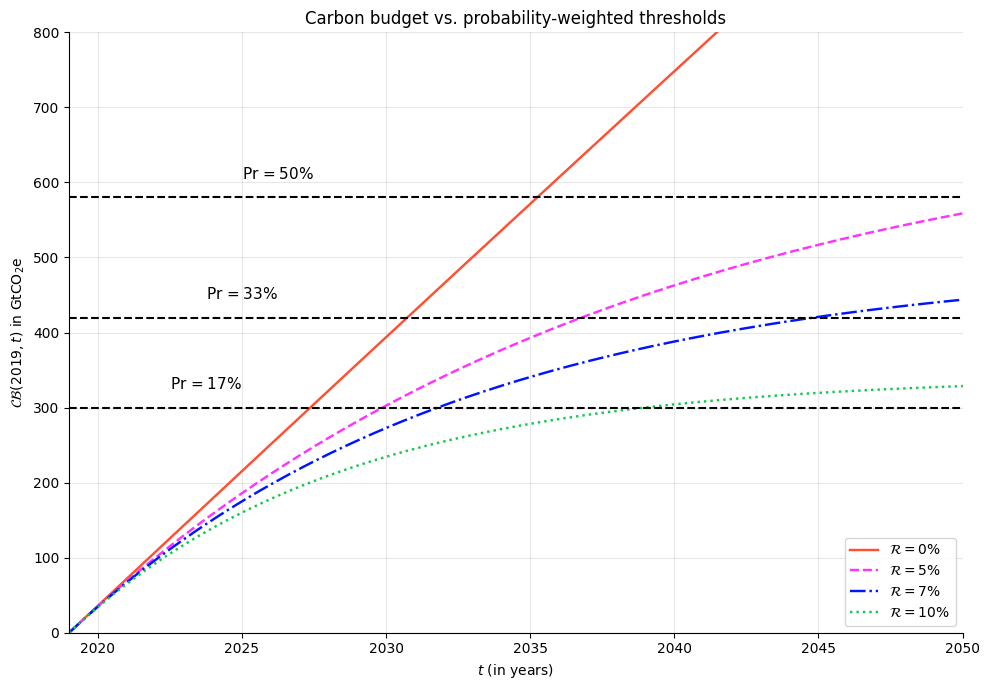

In [5]:

t0 = 2019
t = np.arange(2019, 2019 + 0.1 * 520, 0.1)[: 52 * 10]
CE_t0 = 36
CB_star = [580, 420, 300]
Pr = [50, 33, 17]
R_values = [0.001, 0.05, 0.07, 0.10]

fig, ax = plt.subplots(figsize=(10, 7))
styles = ["-", "--", "-.", ":"]
colors4 = [color_red, color_violet, color_blue, color_green]
for R, ls, c in zip(R_values, styles, colors4):
    CB = ((1 - R) ** (t - t0) - 1) / np.log(1 - R) * CE_t0
    ax.plot(t, CB, ls, color=c, linewidth=1.75, label=fr"$\mathcal{{R}} = {R*100:.0f}\%$")

for i, (cb, pr) in enumerate(zip(CB_star, Pr)):
    ax.axhline(cb, linestyle="--", color=color_black, linewidth=1.5)
    ax.text(2025 - i * 1.25, cb + 25, fr"$\Pr = {pr}\%$", fontsize=11)

ax.set_xlabel("$t$ (in years)")
ax.set_ylabel(r"$\mathcal{CB}(2019, t)$ in GtCO$_2$e")
ax.set_xlim(2019, 2050); ax.set_ylim(0, 800)
ax.grid(True, which="both", alpha=0.3)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.legend(loc="lower right", fontsize=10)
ax.set_title("Carbon budget vs. probability-weighted thresholds")
plt.tight_layout()
plt.show()


## 5. Sector and global emissions scenarios

A worked net-zero-by-2050 scenario, split both by sector (electricity,
buildings, transport, industry, other) and globally (gross emissions,
negative emissions/removals, and their net). Both panels share the same
underlying illustrative data, which is also used below to compute
carbon budgets to several milestone years, both in absolute terms and
as a share of the total 2019-2050 budget.


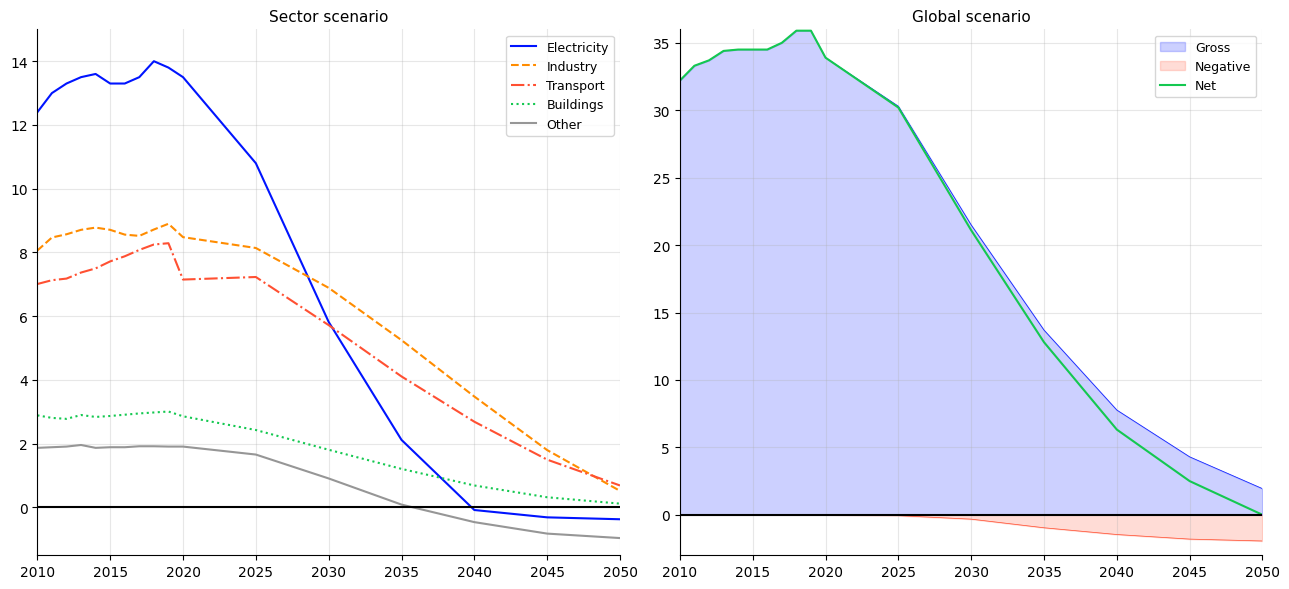

In [6]:

years_row = [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2025, 2030, 2035, 2040, 2045, 2050]
gross =    [32.20, 33.30, 33.70, 34.40, 34.50, 34.50, 34.50, 35.00, 35.90, 35.90, 33.90, 30.30, 21.50, 13.70, 7.77, 4.30, 1.94]
negative = [0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, -0.06, -0.32, -0.96, -1.46, -1.80, -1.94]
net =      [32.20, 33.30, 33.70, 34.40, 34.50, 34.50, 34.50, 35.00, 35.90, 35.90, 33.90, 30.20, 21.10, 12.80, 6.32, 2.50, 0.00]

year1 = np.array(years_row)
data1 = np.array([gross, negative, net]).T

electricity = [12.40, 13.00, 13.30, 13.50, 13.60, 13.30, 13.30, 13.50, 14.00, 13.80, 13.50, 10.80, 5.82, 2.12, -0.08, -0.31, -0.37]
buildings   = [2.89, 2.81, 2.78, 2.90, 2.84, 2.87, 2.91, 2.95, 2.98, 3.01, 2.86, 2.43, 1.81, 1.21, 0.69, 0.32, 0.12]
transport   = [7.01, 7.13, 7.18, 7.37, 7.50, 7.72, 7.88, 8.08, 8.25, 8.29, 7.15, 7.23, 5.72, 4.11, 2.69, 1.50, 0.69]
industry    = [8.06, 8.47, 8.57, 8.71, 8.78, 8.71, 8.56, 8.52, 8.72, 8.90, 8.48, 8.14, 6.89, 5.25, 3.48, 1.80, 0.52]
other       = [1.87, 1.89, 1.91, 1.96, 1.87, 1.89, 1.89, 1.92, 1.92, 1.91, 1.91, 1.66, 0.91, 0.09, -0.46, -0.82, -0.96]

year2 = np.array(years_row)
data2 = np.array([electricity, industry, transport, buildings, other]).T
str2 = ["Electricity", "Industry", "Transport", "Buildings", "Other"]

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

ax = axes[0]
colors5 = [color_blue, color_darkorange, color_red, color_green, color_gray]
styles5 = ["-", "--", "-.", ":", "-"]
for j, (c, ls, lbl) in enumerate(zip(colors5, styles5, str2)):
    ax.plot(year2, data2[:, j], ls, color=c, linewidth=1.5, label=lbl)
ax.axhline(0, color=color_black, linewidth=1.5)
ax.set_title("Sector scenario", fontsize=11)
ax.set_xlim(2010, 2050); ax.set_ylim(-1.5, 15)
ax.grid(True, alpha=0.3)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.legend(loc="upper right", fontsize=9)

ax = axes[1]
ax.plot(year1, data1[:, 0], "-", color=color_blue, linewidth=0.5)
ax.plot(year1, data1[:, 1], "-", color=color_red, linewidth=0.5)
ax.plot(year1, data1[:, 2], "-", color=color_green, linewidth=1.5, label="Net")
ax.axhline(0, color=color_black, linewidth=1.5)
ax.fill_between(year1, data1[:, 0], 0, color=color_blue, alpha=0.20, label="Gross")
ax.fill_between(year1, data1[:, 1], 0, color=color_red, alpha=0.20, label="Negative")
ax.set_title("Global scenario", fontsize=11)
ax.set_xlim(2010, 2050); ax.set_ylim(-3, 36)
ax.grid(True, alpha=0.3)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
handles, labels = ax.get_legend_handles_labels()
ax.legend([handles[i] for i in (1, 2, 0)], [labels[i] for i in (1, 2, 0)], loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()


In [7]:

CE_t = np.column_stack([data2, data1[:, 0]])  # 5 sectors + global gross
str_all = str2 + ["Gross"]
t_end_list = [2025, 2030, 2040, 2045, 2050]

CB_table = np.zeros((len(t_end_list), CE_t.shape[1]))
for j in range(CE_t.shape[1]):
    f = interp1d(year1, CE_t[:, j], kind="linear")
    for i, te in enumerate(t_end_list):
        # CE_t is itself piecewise-linear between year1's knots, so the trapezoidal
        # rule over those same knots is the *exact* integral (not an approximation) --
        # simpler and more robust here than scipy.integrate.quad, which struggles with
        # the kinks in the interpolant across a wide interval.
        knots_in_range = year1[(year1 > 2019) & (year1 < te)]
        tt = np.unique(np.concatenate([[2019], knots_in_range, [te]]))
        CB_table[i, j] = np.trapezoid(f(tt), tt)

cb_df = pd.DataFrame(CB_table, index=t_end_list, columns=str_all)
print("Carbon budget CB(2019, t) by sector/global, GtCO2e:")
display(cb_df.round(1))

ratio_df = 100 * cb_df.div(cb_df.iloc[-1], axis=1)
print("\nShare of the full 2019-2050 budget already 'spent' by each milestone year (%):")
display(ratio_df.round(1))


Carbon budget CB(2019, t) by sector/global, GtCO2e:


,Electricity,Industry,Transport,Buildings,Other,Gross
2025,74.4,50.2,43.7,16.2,10.8,195.4
2030,116.0,87.8,76.0,26.8,17.3,324.9
2040,140.9,140.0,117.6,39.1,18.8,466.6
2045,139.9,153.2,128.1,41.6,15.6,496.8
2050,138.2,159.0,133.6,42.7,11.2,512.4



Share of the full 2019-2050 budget already 'spent' by each milestone year (%):


,Electricity,Industry,Transport,Buildings,Other,Gross
2025,53.8,31.6,32.7,37.9,96.9,38.1
2030,83.9,55.2,56.9,62.7,154.3,63.4
2040,101.9,88.0,88.1,91.5,168.4,91.1
2045,101.2,96.4,95.9,97.4,139.8,97.0
2050,100.0,100.0,100.0,100.0,100.0,100.0


## Summary

This notebook establishes the carbon-budget vocabulary the rest of
Chapter 9 builds on: cumulative emissions over a horizon, closed-form
reduction models, piecewise-linear multi-period accounting, and
probability-weighted thresholds tied to warming targets. The
`carbon_budget_Reduction` and `carbon_budget_piecewise` helpers defined
here are reused in later Chapter 9 notebooks that build on the same
carbon-budget mechanics.
